In [1]:
# 必要なライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # モデルの保存に使用
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import os

# --- 1. データの読み込み ---
features_data_path = '../data/processed/features.parquet'
df = pd.read_parquet(features_data_path)

In [2]:
df.head()

,ID,種類,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,間取り,面積（㎡）,...,間取り_grouped_１ＬＤＫ,間取り_grouped_１Ｒ,間取り_grouped_２ＤＫ,間取り_grouped_２Ｋ,間取り_grouped_２ＬＤＫ,間取り_grouped_２ＬＤＫ＋Ｓ,間取り_grouped_３ＤＫ,間取り_grouped_３ＬＤＫ,間取り_grouped_４ＤＫ,間取り_grouped_４ＬＤＫ
0,1060685,中古マンション等,1108,北海道,札幌市厚別区,大谷地東,大谷地,8.0,３ＬＤＫ,80,...,0,0,0,0,0,0,0,1,0,0
1,1005580,中古マンション等,1101,北海道,札幌市中央区,南９条西,中島公園,5.0,１ＤＫ,30,...,0,0,0,0,0,0,0,0,0,0
2,1001363,中古マンション等,1101,北海道,札幌市中央区,北３条西,西１１丁目,11.0,３ＬＤＫ,65,...,0,0,0,0,0,0,0,1,0,0
3,1052374,中古マンション等,1108,北海道,札幌市厚別区,厚別中央２条,ひばりが丘(北海道),5.0,４ＬＤＫ,90,...,0,0,0,0,0,0,0,0,0,1
4,1059107,中古マンション等,1108,北海道,札幌市厚別区,厚別東４条,新さっぽろ,12.0,４ＬＤＫ,80,...,0,0,0,0,0,0,0,0,0,1


In [3]:
df.columns

Index(['ID', '種類', '市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）',
       '間取り', '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）',
       '容積率（％）', '取引時点', '取引価格（総額）_log', '取引時点での築年数', '人口密度', '取引の事情等_その他事情有り',
       '取引の事情等_他の権利・負担付き', '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
       '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性', '取引の事情等_関係者間取引',
       '取引の事情等_関係者間取引、瑕疵有りの可能性', '取引の事情等_関係者間取引、調停・競売等', '取引の事情等_その他',
       '改装_改装済', '改装_未改装', '間取り_grouped_その他', '間取り_grouped_オープンフロア',
       '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
       '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
       '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
       '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
       '間取り_grouped_４ＬＤＫ'],
      dtype='object')

# LightGBM

In [4]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## モデル構築

In [6]:

# --- 説明変数・目的変数のセット ---
X = df[['最寄駅：距離（分）', '面積（㎡）',  '建ぺい率（％）', '容積率（％）',
        '取引時点での築年数', '取引の事情等_その他事情有り', '取引の事情等_他の権利・負担付き',
        '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
        '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性',
        '取引の事情等_関係者間取引', '取引の事情等_関係者間取引、瑕疵有りの可能性',
        '取引の事情等_関係者間取引、調停・競売等', '改装_改装済', '間取り_grouped_オープンフロア',
        '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
        '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
        '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
        '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
        '間取り_grouped_４ＬＤＫ','人口密度']]

Y = df['取引価格（総額）_log']


## 実行・結果

In [9]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# LightGBM モデル構築
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1',  # MAEを最適化
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

# 学習
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 275
[LightGBM] [Info] Number of data points in the train set: 441316, number of used features: 26
[LightGBM] [Info] Start training from score 7.278754


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression_l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [10]:
# MAE計算

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 予測
y_pred = model_lgb.predict(X_test)

# 評価指標
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1234
RMSE: 0.1763


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIFを計算
vif = pd.DataFrame()
vif["変数名"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 出力
display(vif)

,変数名,VIF
0,最寄駅：距離（分）,3.817784
1,面積（㎡）,12.282174
2,建ぺい率（％）,77.202200
3,容積率（％）,13.387865
4,取引時点での築年数,3.794871
5,取引の事情等_その他事情有り,1.000218
6,取引の事情等_他の権利・負担付き,1.000133
7,取引の事情等_他の権利・負担付き、調停・競売等,1.000020
8,取引の事情等_瑕疵有りの可能性,1.000191
9,取引の事情等_調停・競売等,1.037639


In [13]:
import japanize_matplotlib

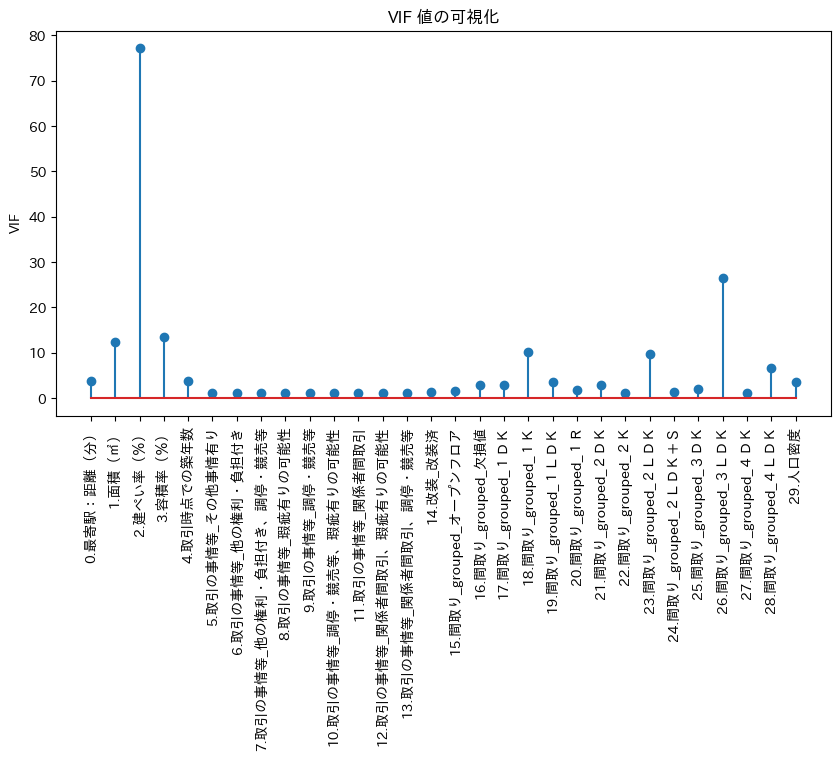

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.stem(vif.index.astype(str) + "." + vif["変数名"], vif["VIF"])
plt.xticks(rotation=90)
plt.ylabel("VIF")
plt.title("VIF 値の可視化")
plt.show()

## 10以下で再学習

In [16]:
# VIF >= 10 の変数を抽出
high_vif_vars = vif[vif["VIF"] >= 10]["変数名"].tolist()

# 高VIF変数を除いた説明変数
X_reduced = X.drop(columns=high_vif_vars)

# 分割
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, Y, test_size=0.2, random_state=42)

# モデル再学習
model_lgb_r = lgb.LGBMRegressor(
    objective='regression_l1',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

model_lgb_r.fit(
    X_train_r, y_train_r,
    eval_set=[(X_test_r, y_test_r)],
    eval_metric='mae',
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 441316, number of used features: 21
[LightGBM] [Info] Start training from score 7.278754


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression_l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
# 予測
y_pred_r = model_lgb_r.predict(X_test_r)

# 評価指標
mae_r = mean_absolute_error(y_test_r, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"[VIF>=10除外後] MAE: {mae_r:.4f}")
print(f"[VIF>=10除外後] RMSE: {rmse_r:.4f}")

[VIF>=10除外後] MAE: 0.1753
[VIF>=10除外後] RMSE: 0.2438


## 20以下

In [18]:
# VIF >= 20 の変数を抽出
high_vif_vars = vif[vif["VIF"] >= 20]["変数名"].tolist()

# 高VIF変数を除いた説明変数
X_reduced = X.drop(columns=high_vif_vars)

# 分割
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, Y, test_size=0.2, random_state=42)

# モデル再学習
model_lgb_r = lgb.LGBMRegressor(
    objective='regression_l1',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

model_lgb_r.fit(
    X_train_r, y_train_r,
    eval_set=[(X_test_r, y_test_r)],
    eval_metric='mae',
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 266
[LightGBM] [Info] Number of data points in the train set: 441316, number of used features: 24
[LightGBM] [Info] Start training from score 7.278754


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression_l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# 予測
y_pred_r = model_lgb_r.predict(X_test_r)

# 評価指標
mae_r = mean_absolute_error(y_test_r, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"[VIF>=20除外後] MAE: {mae_r:.4f}")
print(f"[VIF>=20除外後] RMSE: {rmse_r:.4f}")

[VIF>=10除外後] MAE: 0.1241
[VIF>=10除外後] RMSE: 0.1772
